# DRL Assignment 3: A Unified Deep Q-Learning Workflow

## Lab Overview

This lab follows one continuous path through value-based deep reinforcement learning. We begin with Acrobot, where a compact six-dimensional state makes it easy to see every DQN component clearly. After building, training, and improving that agent, we keep the same Bellman-learning foundation and move to LevDoom Seek and Slay. The new environment introduces pixels and partial observability, which motivates visual preprocessing, recurrent memory, sequence replay, and burn-in.

The final system is therefore not a separate algorithm: it is DQN extended step by step into a recurrent Double-Dueling agent for visual control. The supplied 30,000-step checkpoint is used as an early pipeline milestone, not as evidence of convergence or final performance.

> **Quick terms:** A **Q-value** estimates the discounted return of selecting an action in a state.  
> **Experience replay** reuses stored interactions, and a **target network** stabilizes bootstrap targets.  
> **Double DQN** separates next-action selection from evaluation, while a **dueling network** separates state value from action advantage.  
> A **DRQN** adds recurrent memory for partially observable tasks; **burn-in** initializes that memory before recurrent TD loss is applied.

#### Recommended Hardware

AMD Ryzen™ AI Halo Processors (e.g., AI Max+ 395, AI Max 390) or an AMD GPU supported by ROCm™. Acrobot and checkpoint inspection can run on CPU, while DQN training and the optional LevDoom 30k prototype are faster on an accelerator.

#### Software Environment

OS: Ubuntu 24.04.3 LTS  
Install [AUP Learning Cloud](https://amdresearch.github.io/aup-learning-cloud/installation/quick-start.html). It provides a ROCm and PyTorch environment compatible with this notebook.

## Goals

By the end of this lab, you will:

- Understand the common value-learning structure behind vector and visual control tasks.
- Establish a random baseline and implement a complete DQN agent.
- Use experience replay, target networks, and epsilon-greedy exploration.
- Improve value estimation with Double DQN and Dueling Networks.
- Recognize when image observations require visual features and temporal memory.
- Build a CNN–GRU recurrent Q-network with sequence replay and burn-in.
- Apply reward shaping and curriculum learning across LevDoom levels.
- Load and interpret a 30k prototype checkpoint without overstating its performance.
- Relate the complete workflow to a distributed actor–replay–learner design.

---

## 1. Environment Setup

The AUP Learning Cloud course image already includes PyTorch. This shared setup installs the Gymnasium classic-control renderer, image export support, and LevDoom. All later sections use the same Python kernel, PyTorch device, and reproducibility settings.

In [1]:
%pip install -q "gymnasium[classic-control]" imageio levdoom==1.0.3

Note: you may need to restart the kernel to use updated packages.


In [2]:
import copy
import random
import shlex
import subprocess
import sys
import warnings
from collections import deque, namedtuple
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Deque, Dict, Optional, Sequence, Tuple

import gymnasium as gym
import imageio.v2 as imageio
import levdoom  # Importing LevDoom registers its Gymnasium environments.
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from IPython.display import Image, display
from torch.nn.utils import clip_grad_norm_

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"Accelerator: {torch.cuda.get_device_name(0)}")

OUTPUT_DIR = Path("ddrl_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

PROJECT_DIR = Path("hw3q2_completed_ta").resolve()
CHECKPOINT_30K = PROJECT_DIR / "seek_slay_drqn_30k_test.pt"
if not PROJECT_DIR.is_dir():
    raise FileNotFoundError("Expected hw3q2_completed_ta beside this notebook")
if not CHECKPOINT_30K.is_file():
    raise FileNotFoundError(f"Missing prototype checkpoint: {CHECKPOINT_30K}")

print(f"LevDoom project: {PROJECT_DIR}")
print(f"30k checkpoint:  {CHECKPOINT_30K.name}")

PyTorch version: 2.6.0+cpu
Device: cpu
LevDoom project: /home/yayu0122/hw3q2_completed_ta
30k checkpoint:  seek_slay_drqn_30k_test.pt


In [3]:
def set_seed(seed: int = 42) -> None:
    """Seed Python, NumPy, and PyTorch for reproducible experiments."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(42)

## 2. Two Environments, One Value-Learning Problem

### Acrobot: Compact Vector Control

Acrobot is a two-link, underactuated robot. The first joint is fixed to a support and cannot be actuated; the agent applies torque only at the joint between the links. Its objective is to swing the free end above a target height.

### Observation Space

The observation is a six-dimensional continuous vector:

| Index | Variable | Meaning | Approximate range |
|---:|---|---|---|
| 0 | $\cos(\theta_1)$ | Cosine of link 1 angle | $[-1, 1]$ |
| 1 | $\sin(\theta_1)$ | Sine of link 1 angle | $[-1, 1]$ |
| 2 | $\cos(\theta_2)$ | Cosine of link 2 angle | $[-1, 1]$ |
| 3 | $\sin(\theta_2)$ | Sine of link 2 angle | $[-1, 1]$ |
| 4 | $\dot{\theta}_1$ | Angular velocity of link 1 | $[-4\pi, 4\pi]$ |
| 5 | $\dot{\theta}_2$ | Angular velocity of link 2 | $[-9\pi, 9\pi]$ |

### Action and Reward

| Action | Applied torque |
|---:|---:|
| 0 | $-1$ |
| 1 | $0$ |
| 2 | $+1$ |

The environment returns $-1$ at every step before success. Therefore, a return closer to zero represents a faster swing-up. An episode ends when the goal is reached (**terminated**) or when the time limit is reached (**truncated**).

The distinction matters during learning: a true terminal state has no future value, whereas a time-limit truncation is not necessarily terminal in the underlying task. We stop the rollout for either condition but mask bootstrapping only for `terminated` transitions.

In [4]:
env = gym.make("Acrobot-v1", render_mode="rgb_array")
observation, info = env.reset(seed=42)

print("Environment specifications")
print(f"  Observation space: {env.observation_space}")
print(f"  Action space:      {env.action_space}")
print(f"  Maximum steps:     {env.spec.max_episode_steps}")
print(f"  Sample state:      {np.round(observation, 3)}")

plt.figure(figsize=(5, 5))
plt.imshow(env.render())
plt.axis("off")
plt.title("Initial Acrobot state")
plt.show()
env.close()

Environment specifications
  Observation space: Box([ -1.        -1.        -1.        -1.       -12.566371 -28.274334], [ 1.        1.        1.        1.       12.566371 28.274334], (6,), float32)
  Action space:      Discrete(3)
  Maximum steps:     500
  Sample state:      [ 0.998  0.055  1.    -0.012  0.072  0.039]


### Seek and Slay: Visual Control with Memory

The reference policy shares one network across five levels. The action space contains 12 discrete actions, while the observation is a first-person image. Different levels contribute different weights to the final metric.

| Evaluation level | Weight |
|---|---:|
| SeekAndSlayLevel0-v0 | 1 |
| SeekAndSlayLevel1_6-v0 | 2 |
| SeekAndSlayLevel3_1-v0 | 2 |
| SeekAndSlayLevel2_3-v0 | 2 |
| SeekAndSlayLevel4-v0 | 3 |

The score used by the reference evaluator is

$$
\text{score}=\sum_l w_l\left(\text{kills}_l+0.01\,\text{health}_l+0.005\,\text{ammo}_l\right).
$$

The current image may not reveal an opponent that was visible a moment ago, and motion direction cannot always be inferred from one frame. This makes temporal memory useful.

In [5]:
LEVEL_IDS = (
    "SeekAndSlayLevel0-v0",
    "SeekAndSlayLevel1_6-v0",
    "SeekAndSlayLevel3_1-v0",
    "SeekAndSlayLevel2_3-v0",
    "SeekAndSlayLevel4-v0",
)
LEVEL_WEIGHTS = (1.0, 2.0, 2.0, 2.0, 3.0)


def make_env(level_id: str):
    """Support LevDoom versions with or without the render keyword."""
    try:
        return gym.make(level_id, render=False)
    except TypeError:
        return gym.make(level_id)


env = make_env(LEVEL_IDS[0])
observation, info = env.reset(seed=42)
print(f"Observation space: {env.observation_space}")
print(f"Action space:      {env.action_space}")
print(f"Observation type:  {type(observation).__name__}")
env.close()

Observation space: Box(0, 255, (240, 320, 3), uint8)
Action space:      Discrete(12)
Observation type:  ndarray


### What Changes—and What Stays the Same

| Component | Acrobot | Seek and Slay |
|---|---|---|
| Observation | Six continuous values | First-person RGB image |
| Action space | Three discrete torques | Twelve discrete actions |
| Temporal information | Mostly represented in the state vector | Must be inferred from recent frames |
| Replay unit | Individual transition | Contiguous episode sequence |
| Q-learning target | Bellman target with a target network | The same target applied across recurrent sequences |

Both tasks ask the network to estimate action values. The later architectural changes address the observation and memory requirements; they do not replace the underlying DQN objective.

## 3. Establishing a Random Baseline

A random agent does not learn; it samples each action from the environment's action space. This baseline verifies that the environment and rendering pipeline work, and it provides a reference return for the learned agents.

Random policy | return: -500 | episode length: 500


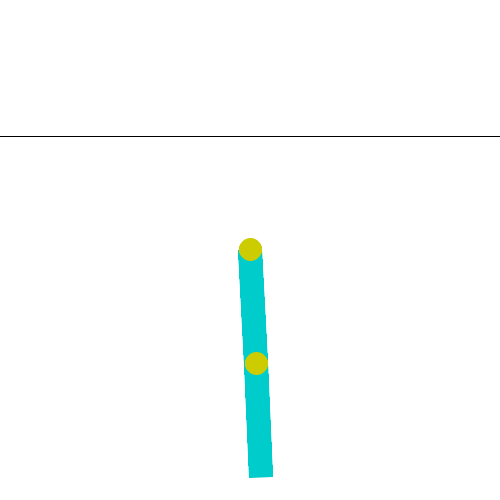

In [6]:
def run_random_agent(seed: int = 42, filename: str = "random_agent.gif"):
    env = gym.make("Acrobot-v1", render_mode="rgb_array")
    env.action_space.seed(seed)
    state, _ = env.reset(seed=seed)
    frames = [env.render()]
    total_reward = 0.0
    steps = 0
    done = False

    while not done:
        action = env.action_space.sample()
        state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        total_reward += reward
        steps += 1
        frames.append(env.render())

    env.close()
    gif_path = OUTPUT_DIR / filename
    imageio.mimsave(gif_path, frames, fps=30, loop=0)
    return gif_path, total_reward, steps


random_gif, random_return, random_steps = run_random_agent()
print(f"Random policy | return: {random_return:.0f} | episode length: {random_steps}")
display(Image(filename=str(random_gif)))

## 4. Learning Action Values with DQN

For a discrete action space, DQN uses a neural network $Q_\theta(s,a)$ to predict one Q-value per action. The greedy policy selects

$$
a_t = \arg\max_a Q_\theta(s_t,a).
$$

During training, epsilon-greedy exploration selects a random action with probability $\epsilon$ and the greedy action otherwise. We linearly reduce $\epsilon$ as the agent gathers experience.

For a sampled transition $(s,a,r,s',d)$, basic DQN uses the target

$$
y = r + \gamma(1-d)\max_{a'}Q_{\theta^-}(s',a'),
$$

where $\theta^-$ denotes the target-network parameters and $d=1$ only for a true terminal transition. The online network minimizes the Huber loss between $Q_\theta(s,a)$ and $y$.

Two mechanisms improve stability:

1. **Experience replay** breaks short-term correlations by sampling transitions uniformly from a buffer.
2. **Target network** holds the bootstrap target fixed for several updates before copying the online-network weights.

## 5. Building the DQN Agent

### Q-Network

The Acrobot state is already a compact feature vector, so a multilayer perceptron is sufficient. The output has one value for each of the three discrete actions.

In [7]:
class QNetwork(nn.Module):
    """Multilayer perceptron that predicts one Q-value per action."""

    def __init__(self, obs_dim: int, action_dim: int, hidden_dim: int = 128):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim),
        )

    def forward(self, states: torch.Tensor) -> torch.Tensor:
        return self.network(states)


sample_network = QNetwork(obs_dim=6, action_dim=3).to(device)
sample_states = torch.zeros(4, 6, device=device)
print("Input batch shape: ", tuple(sample_states.shape))
print("Q-value shape:     ", tuple(sample_network(sample_states).shape))

Input batch shape:  (4, 6)
Q-value shape:      (4, 3)


### Transition Replay

Each stored transition contains the current state, selected action, reward, next state, and the **terminated** flag. Uniform random sampling returns a mini-batch for a gradient update.

In [8]:
Transition = namedtuple(
    "Transition", ["state", "action", "reward", "next_state", "terminated"]
)


class ReplayBuffer:
    """Fixed-capacity replay memory with uniform random sampling."""

    def __init__(self, capacity: int):
        self.memory = deque(maxlen=capacity)

    def push(
        self,
        state: np.ndarray,
        action: int,
        reward: float,
        next_state: np.ndarray,
        terminated: bool,
    ) -> None:
        self.memory.append(
            Transition(
                np.asarray(state, dtype=np.float32).copy(),
                int(action),
                float(reward),
                np.asarray(next_state, dtype=np.float32).copy(),
                bool(terminated),
            )
        )

    def sample(self, batch_size: int):
        batch = random.sample(self.memory, batch_size)
        states = np.asarray([item.state for item in batch], dtype=np.float32)
        actions = np.asarray([item.action for item in batch], dtype=np.int64)
        rewards = np.asarray([item.reward for item in batch], dtype=np.float32)
        next_states = np.asarray([item.next_state for item in batch], dtype=np.float32)
        terminated = np.asarray([item.terminated for item in batch], dtype=np.float32)
        return states, actions, rewards, next_states, terminated

    def __len__(self) -> int:
        return len(self.memory)

### Configuration and Agent

The configuration collects the experiment's hyperparameters in one place. The agent supports both basic DQN and Double DQN; the `double_dqn` switch changes only how the next action is selected for the target.

In [9]:
@dataclass(frozen=True)
class DQNConfig:
    env_id: str = "Acrobot-v1"
    hidden_dim: int = 128
    gamma: float = 0.99
    learning_rate: float = 5e-4
    buffer_capacity: int = 100_000
    batch_size: int = 128
    warmup_steps: int = 1_000
    train_frequency: int = 1
    target_update_interval: int = 500
    max_grad_norm: float = 10.0
    epsilon_start: float = 1.0
    epsilon_end: float = 0.05
    epsilon_decay_steps: int = 50_000
    num_episodes: int = 350
    validation_interval: int = 25
    validation_episodes: int = 5
    validation_seed: int = 500

In [10]:
class DQNAgent:
    """DQN agent with replay memory, target network, and optional Double DQN."""

    def __init__(
        self,
        obs_dim: int,
        action_dim: int,
        config: DQNConfig,
        network_cls=QNetwork,
        double_dqn: bool = False,
    ):
        self.obs_dim = obs_dim
        self.action_dim = action_dim
        self.config = config
        self.double_dqn = double_dqn

        self.online_network = network_cls(
            obs_dim, action_dim, config.hidden_dim
        ).to(device)
        self.target_network = network_cls(
            obs_dim, action_dim, config.hidden_dim
        ).to(device)
        self.target_network.load_state_dict(self.online_network.state_dict())
        self.target_network.eval()

        self.optimizer = optim.Adam(
            self.online_network.parameters(), lr=config.learning_rate
        )
        self.replay_buffer = ReplayBuffer(config.buffer_capacity)
        self.env_steps = 0
        self.gradient_steps = 0

    def epsilon(self) -> float:
        progress = min(self.env_steps / self.config.epsilon_decay_steps, 1.0)
        return self.config.epsilon_start + progress * (
            self.config.epsilon_end - self.config.epsilon_start
        )

    def select_action(self, state: np.ndarray, epsilon: float | None = None) -> int:
        epsilon = self.epsilon() if epsilon is None else epsilon
        if epsilon > 0.0 and random.random() < epsilon:
            return random.randrange(self.action_dim)

        state_tensor = torch.as_tensor(
            state, dtype=torch.float32, device=device
        ).unsqueeze(0)
        with torch.no_grad():
            q_values = self.online_network(state_tensor)
        return int(q_values.argmax(dim=1).item())

    def observe(
        self,
        state: np.ndarray,
        action: int,
        reward: float,
        next_state: np.ndarray,
        terminated: bool,
    ) -> None:
        self.replay_buffer.push(state, action, reward, next_state, terminated)
        self.env_steps += 1

    def learn(self) -> float | None:
        cfg = self.config
        if len(self.replay_buffer) < max(cfg.warmup_steps, cfg.batch_size):
            return None
        if self.env_steps % cfg.train_frequency != 0:
            return None

        states, actions, rewards, next_states, terminated = (
            self.replay_buffer.sample(cfg.batch_size)
        )
        states = torch.as_tensor(states, dtype=torch.float32, device=device)
        actions = torch.as_tensor(actions, dtype=torch.long, device=device).unsqueeze(1)
        rewards = torch.as_tensor(rewards, dtype=torch.float32, device=device)
        next_states = torch.as_tensor(
            next_states, dtype=torch.float32, device=device
        )
        terminated = torch.as_tensor(
            terminated, dtype=torch.float32, device=device
        )

        predicted_q = self.online_network(states).gather(1, actions).squeeze(1)

        with torch.no_grad():
            if self.double_dqn:
                next_actions = self.online_network(next_states).argmax(
                    dim=1, keepdim=True
                )
                next_q = self.target_network(next_states).gather(
                    1, next_actions
                ).squeeze(1)
            else:
                next_q = self.target_network(next_states).max(dim=1).values

            target_q = rewards + cfg.gamma * (1.0 - terminated) * next_q

        loss = nn.functional.smooth_l1_loss(predicted_q, target_q)
        self.optimizer.zero_grad(set_to_none=True)
        loss.backward()
        clip_grad_norm_(self.online_network.parameters(), cfg.max_grad_norm)
        self.optimizer.step()
        self.gradient_steps += 1

        if self.env_steps % cfg.target_update_interval == 0:
            self.update_target_network()

        return float(loss.item())

    def update_target_network(self) -> None:
        self.target_network.load_state_dict(self.online_network.state_dict())

## 6. Training and Evaluating on Acrobot

One training episode repeatedly selects an epsilon-greedy action, stores the transition, and performs a replay update. Episode reset seeds are varied deterministically so that repeated runs are reproducible without presenting exactly the same initial state every time.

DQN learning can be unstable: a later target-network update may make the final weights worse even when the recent training return looks good. Every 25 episodes, we therefore evaluate the greedy policy on five fixed **validation seeds** and retain the best weights. The Python random state is restored after validation so that model selection does not change the subsequent exploration sequence.

The final policy is reported on a separate set of **test seeds** in the evaluation section. The default 350 episodes are intended to produce a useful policy, but results can still vary across hardware and software versions. For a quick pipeline check, temporarily reduce **num_episodes**; restore it before comparing agents.

In [11]:
def mean_validation_return(
    agent: DQNAgent,
    n_episodes: int,
    seed: int,
) -> float:
    """Evaluate on fixed validation seeds without perturbing training RNG."""
    python_random_state = random.getstate()
    env = gym.make(agent.config.env_id)
    returns = []
    agent.online_network.eval()

    try:
        for episode in range(n_episodes):
            state, _ = env.reset(seed=seed + episode)
            total_reward = 0.0
            done = False

            while not done:
                action = agent.select_action(state, epsilon=0.0)
                state, reward, terminated, truncated, _ = env.step(action)
                total_reward += reward
                done = terminated or truncated

            returns.append(total_reward)
    finally:
        env.close()
        random.setstate(python_random_state)
        agent.online_network.train()

    return float(np.mean(returns))


def train_agent(
    config: DQNConfig,
    network_cls=QNetwork,
    double_dqn: bool = False,
    seed: int = 42,
    label: str = "DQN",
):
    set_seed(seed)
    env = gym.make(config.env_id)
    env.action_space.seed(seed)
    obs_dim = int(np.prod(env.observation_space.shape))
    action_dim = int(env.action_space.n)
    agent = DQNAgent(
        obs_dim,
        action_dim,
        config,
        network_cls=network_cls,
        double_dqn=double_dqn,
    )

    reward_history = []
    loss_history = []
    validation_history = []
    best_validation_return = -float("inf")
    best_state_dict = None

    for episode in range(1, config.num_episodes + 1):
        state, _ = env.reset(seed=seed + episode)
        state = state.astype(np.float32)
        episode_reward = 0.0
        done = False

        while not done:
            action = agent.select_action(state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            next_state = next_state.astype(np.float32)

            # Stop the rollout on termination or truncation, but mask the
            # Bellman bootstrap only for a true terminal transition.
            agent.observe(state, action, reward, next_state, terminated)
            loss = agent.learn()
            if loss is not None:
                loss_history.append(loss)

            state = next_state
            episode_reward += reward
            done = terminated or truncated

        reward_history.append(episode_reward)
        validation_score = None

        if episode % config.validation_interval == 0:
            validation_score = mean_validation_return(
                agent,
                n_episodes=config.validation_episodes,
                seed=config.validation_seed,
            )
            validation_history.append((episode, validation_score))

            if validation_score > best_validation_return:
                best_validation_return = validation_score
                best_state_dict = copy.deepcopy(agent.online_network.state_dict())

        if episode == 1 or episode % 25 == 0:
            recent_mean = np.mean(reward_history[-25:])
            validation_text = (
                f" | validation {validation_score:7.2f}"
                if validation_score is not None
                else ""
            )
            print(
                f"{label:18s} | episode {episode:3d}/{config.num_episodes} "
                f"| return {episode_reward:6.1f} | mean(25) {recent_mean:7.2f} "
                f"| epsilon {agent.epsilon():.3f}{validation_text}"
            )

    env.close()

    if best_state_dict is None:
        raise RuntimeError("No validation checkpoint was produced")

    agent.online_network.load_state_dict(best_state_dict)
    agent.update_target_network()
    agent.best_validation_return = best_validation_return
    agent.validation_history = validation_history
    return agent, reward_history, loss_history


def moving_average(values, window: int = 20):
    values = np.asarray(values, dtype=np.float32)
    if len(values) < window:
        return np.arange(len(values)), values
    smoothed = np.convolve(values, np.ones(window) / window, mode="valid")
    x = np.arange(window - 1, len(values))
    return x, smoothed

In [12]:
config = DQNConfig()
dqn_agent, dqn_rewards, dqn_losses = train_agent(
    config,
    network_cls=QNetwork,
    double_dqn=False,
    seed=42,
    label="DQN",
)

DQN                | episode   1/350 | return -500.0 | mean(25) -500.00 | epsilon 0.991


DQN                | episode  25/350 | return -404.0 | mean(25) -481.20 | epsilon 0.771 | validation -116.00


DQN                | episode  50/350 | return -311.0 | mean(25) -320.36 | epsilon 0.619 | validation -500.00


DQN                | episode  75/350 | return -261.0 | mean(25) -246.64 | epsilon 0.501 | validation -500.00


DQN                | episode 100/350 | return -114.0 | mean(25) -180.24 | epsilon 0.415 | validation -500.00


...

DQN                | episode 250/350 | return  -90.0 | mean(25)  -92.08 | epsilon 0.050 | validation -263.40


DQN                | episode 275/350 | return  -98.0 | mean(25)  -96.56 | epsilon 0.050 | validation -500.00


DQN                | episode 300/350 | return -107.0 | mean(25)  -87.04 | epsilon 0.050 | validation -260.80


DQN                | episode 325/350 | return  -83.0 | mean(25)  -94.08 | epsilon 0.050 | validation  -96.80


DQN                | episode 350/350 | return -104.0 | mean(25)  -95.84 | epsilon 0.050 | validation -414.80


In [13]:
x, dqn_average = moving_average(dqn_rewards, window=20)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(dqn_rewards, alpha=0.25, label="Episode return")
axes[0].plot(x, dqn_average, linewidth=2, label="20-episode mean")
axes[0].set(title="DQN training returns", xlabel="Episode", ylabel="Return")
axes[0].legend()

axes[1].plot(dqn_losses, alpha=0.7)
axes[1].set(title="DQN optimization loss", xlabel="Gradient step", ylabel="Huber loss")
plt.tight_layout()
plt.show()

### Policy Evaluation

Evaluation uses ten test seeds that are separate from the five validation seeds used for checkpoint selection. It disables exploration by setting $\epsilon=0$. We report returns over multiple independently seeded episodes and record one rollout as a GIF. The mean return is more informative than a single episode because environment initial states vary.

In [14]:
def evaluate_agent(agent: DQNAgent, n_episodes: int = 10, seed: int = 1_000):
    env = gym.make(agent.config.env_id)
    rewards, lengths = [], []

    for episode in range(n_episodes):
        state, _ = env.reset(seed=seed + episode)
        total_reward = 0.0
        done = False
        steps = 0

        while not done:
            action = agent.select_action(state, epsilon=0.0)
            state, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            steps += 1
            done = terminated or truncated

        rewards.append(total_reward)
        lengths.append(steps)

    env.close()
    return {
        "rewards": np.asarray(rewards, dtype=np.float32),
        "lengths": np.asarray(lengths, dtype=np.int32),
        "mean_return": float(np.mean(rewards)),
        "std_return": float(np.std(rewards)),
    }


def record_agent(
    agent: DQNAgent,
    filename: str,
    seed: int = 2_000,
    fps: int = 30,
):
    env = gym.make(agent.config.env_id, render_mode="rgb_array")
    state, _ = env.reset(seed=seed)
    frames = [env.render()]
    total_reward = 0.0
    done = False

    while not done:
        action = agent.select_action(state, epsilon=0.0)
        state, reward, terminated, truncated, _ = env.step(action)
        total_reward += reward
        done = terminated or truncated
        frames.append(env.render())

    env.close()
    gif_path = OUTPUT_DIR / filename
    imageio.mimsave(gif_path, frames, fps=fps, loop=0)
    return gif_path, total_reward, len(frames) - 1

DQN evaluation | mean return: -81.30 ± 8.60
Episode returns: [-91, -98, -84, -91, -75, -74, -75, -78, -73, -74]


Recorded rollout | return: -83 | steps: 84


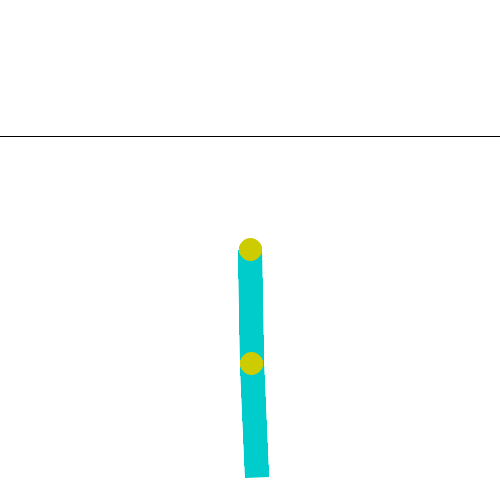

In [15]:
dqn_metrics = evaluate_agent(dqn_agent)
print(
    f"DQN evaluation | mean return: {dqn_metrics['mean_return']:.2f} "
    f"± {dqn_metrics['std_return']:.2f}"
)
print("Episode returns:", dqn_metrics["rewards"].astype(int).tolist())

dqn_gif, dqn_return, dqn_steps = record_agent(
    dqn_agent, "dqn_evaluation.gif"
)
print(f"Recorded rollout | return: {dqn_return:.0f} | steps: {dqn_steps}")
display(Image(filename=str(dqn_gif)))

## 7. Improving Value Estimates: Double and Dueling DQN

### Double DQN

The max operator in basic DQN uses the same noisy estimates to select and evaluate an action, which can produce optimistic value estimates. Double DQN separates these roles:

$$
a^* = \arg\max_{a'}Q_\theta(s',a'), \qquad
y = r + \gamma(1-d)Q_{\theta^-}(s',a^*).
$$

The online network selects $a^*$; the target network evaluates it.

### Dueling Network

In some states, the choice of action matters less than the overall quality of the state. A dueling network represents a scalar state value $V(s)$ and action advantages $A(s,a)$ separately, then combines them as

$$
Q(s,a)=V(s)+A(s,a)-\frac{1}{|\mathcal{A}|}\sum_{a'}A(s,a').
$$

Mean-centering the advantages makes the decomposition identifiable. Double DQN changes the learning target, while the dueling architecture changes the network representation; they can therefore be used together.

In [16]:
class DuelingQNetwork(nn.Module):
    """Dueling architecture with shared features and separate value/advantage heads."""

    def __init__(self, obs_dim: int, action_dim: int, hidden_dim: int = 128):
        super().__init__()
        self.features = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )
        self.value_head = nn.Linear(hidden_dim, 1)
        self.advantage_head = nn.Linear(hidden_dim, action_dim)

    def forward(self, states: torch.Tensor) -> torch.Tensor:
        features = self.features(states)
        value = self.value_head(features)
        advantage = self.advantage_head(features)
        return value + advantage - advantage.mean(dim=1, keepdim=True)


dueling_network = DuelingQNetwork(obs_dim=6, action_dim=3).to(device)
print("Dueling-network output shape:", tuple(dueling_network(sample_states).shape))

Dueling-network output shape: (4, 3)


In [17]:
double_dueling_agent, improved_rewards, improved_losses = train_agent(
    config,
    network_cls=DuelingQNetwork,
    double_dqn=True,
    seed=42,
    label="Double + Dueling",
)

Double + Dueling   | episode   1/350 | return -500.0 | mean(25) -500.00 | epsilon 0.991


Double + Dueling   | episode  25/350 | return -492.0 | mean(25) -499.48 | epsilon 0.763 | validation -500.00


Double + Dueling   | episode  50/350 | return -188.0 | mean(25) -330.08 | epsilon 0.606 | validation -500.00


Double + Dueling   | episode  75/350 | return -198.0 | mean(25) -216.24 | epsilon 0.502 | validation -500.00


Double + Dueling   | episode 100/350 | return -156.0 | mean(25) -170.48 | epsilon 0.421 | validation -500.00


...

Double + Dueling   | episode 250/350 | return  -83.0 | mean(25)  -93.36 | epsilon 0.075 | validation  -84.00


Double + Dueling   | episode 275/350 | return  -86.0 | mean(25)  -86.36 | epsilon 0.050 | validation  -79.00


Double + Dueling   | episode 300/350 | return  -93.0 | mean(25)  -88.44 | epsilon 0.050 | validation -500.00


Double + Dueling   | episode 325/350 | return -109.0 | mean(25)  -86.80 | epsilon 0.050 | validation  -83.40


Double + Dueling   | episode 350/350 | return -102.0 | mean(25)  -92.96 | epsilon 0.050 | validation  -81.60


### Comparing the Agents on Acrobot

A fair comparison keeps the environment, training budget, optimizer settings, evaluation seeds, and most hyperparameters fixed. Because a single seed can be misleading, a more rigorous study repeats training with several seeds and reports confidence intervals.

Evaluation summary (10 episodes, identical seeds)
  DQN:                    -81.30 ± 8.60
  Double + Dueling DQN:   -84.70 ± 9.63
  Mean-return change:      -3.40


Recorded improved rollout | return: -85 | steps: 86


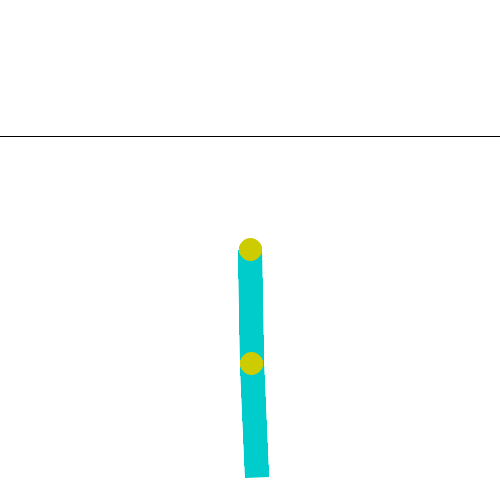

In [18]:
dqn_x, dqn_mean = moving_average(dqn_rewards, window=20)
improved_x, improved_mean = moving_average(improved_rewards, window=20)

plt.figure(figsize=(10, 5))
plt.plot(dqn_x, dqn_mean, label="DQN", linewidth=2)
plt.plot(improved_x, improved_mean, label="Double + Dueling DQN", linewidth=2)
plt.xlabel("Episode")
plt.ylabel("20-episode mean return")
plt.title("Training comparison on Acrobot-v1")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

improved_metrics = evaluate_agent(double_dueling_agent)
print("Evaluation summary (10 episodes, identical seeds)")
print(
    f"  DQN:                  {dqn_metrics['mean_return']:8.2f} "
    f"± {dqn_metrics['std_return']:.2f}"
)
print(
    f"  Double + Dueling DQN: {improved_metrics['mean_return']:8.2f} "
    f"± {improved_metrics['std_return']:.2f}"
)
print(
    f"  Mean-return change:   "
    f"{improved_metrics['mean_return'] - dqn_metrics['mean_return']:+8.2f}"
)

improved_gif, improved_return, improved_steps = record_agent(
    double_dueling_agent, "double_dueling_dqn_evaluation.gif"
)
print(
    f"Recorded improved rollout | return: {improved_return:.0f} "
    f"| steps: {improved_steps}"
)
display(Image(filename=str(improved_gif)))

### Interpreting the Comparison

Double DQN and Dueling Networks address specific estimation and representation issues; they do not guarantee a higher return in every finite training run. The printed result comes from one training seed and ten test episodes. A small positive or negative difference should therefore be treated as run-to-run variation, not as proof that one architecture is universally superior.

A defensible performance claim requires several independent training seeds, the same validation and test protocol for every method, and uncertainty estimates across runs.

## 8. Moving from State Vectors to Pixels

The Acrobot networks receive already-structured state vectors. Seek and Slay instead supplies images, so the agent must first construct a compact visual representation. This is the first extension of the DQN pipeline; the Bellman target and action-value interpretation remain unchanged.

### Visual Preprocessing

The preprocessing pipeline accepts either a raw image or an observation dictionary, handles both HWC and CHW layouts, converts RGB to luminance, resizes to $84\times84$, and stores the result as unsigned 8-bit integers.

Keeping replay frames as **uint8** uses one quarter of the memory required by float32. Frames are normalized to $[0,1]$ only when a training batch is moved to the selected device.

In [19]:
def extract_image(obs: Any) -> np.ndarray:
    if isinstance(obs, dict):
        for key in ("observation", "image", "rgb", "screen"):
            if key in obs:
                return np.asarray(obs[key])
        for value in obs.values():
            array = np.asarray(value)
            if array.ndim == 3:
                return array
        raise ValueError("Could not find an RGB image in observation dictionary")
    return np.asarray(obs)


def preprocess_frame_uint8(obs: Any, image_size: int = 84) -> np.ndarray:
    """Convert a LevDoom observation to resized grayscale uint8."""
    image = extract_image(obs)
    if image.ndim != 3:
        raise ValueError(f"Expected a 3-D image, got shape {image.shape}")

    # Accept both channels-last (HWC) and channels-first (CHW) layouts.
    if image.shape[0] in (1, 3, 4) and image.shape[-1] not in (1, 3, 4):
        image = np.transpose(image, (1, 2, 0))

    if image.shape[-1] == 1:
        gray = image[..., 0].astype(np.float32)
    else:
        rgb = image[..., :3].astype(np.float32)
        gray = (
            0.299 * rgb[..., 0]
            + 0.587 * rgb[..., 1]
            + 0.114 * rgb[..., 2]
        )

    tensor = torch.from_numpy(gray).unsqueeze(0).unsqueeze(0)
    tensor = F.interpolate(
        tensor,
        size=(image_size, image_size),
        mode="bilinear",
        align_corners=False,
    )
    tensor = tensor.squeeze(0).squeeze(0).clamp_(0.0, 255.0)
    return tensor.round().to(torch.uint8).cpu().numpy()

In [20]:
env = make_env(LEVEL_IDS[0])
observation, _ = env.reset(seed=42)
raw_image = extract_image(observation)
processed_frame = preprocess_frame_uint8(observation)
env.close()

display_image = raw_image
if raw_image.shape[0] in (1, 3, 4) and raw_image.shape[-1] not in (1, 3, 4):
    display_image = np.transpose(raw_image, (1, 2, 0))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(display_image[..., :3])
axes[0].set_title(f"Raw observation: {raw_image.shape}")
axes[1].imshow(processed_frame, cmap="gray", vmin=0, vmax=255)
axes[1].set_title(f"Replay frame: {processed_frame.shape}, {processed_frame.dtype}")
for axis in axes:
    axis.axis("off")
plt.tight_layout()
plt.show()

## 9. Adding Memory with a Recurrent Dueling Q-Network

The model processes a batch of frame sequences with shape $[B,T,1,84,84]$:

| Stage | Purpose | Output role |
|---|---|---|
| CNN encoder | Extract spatial features from each frame | Visual representation |
| Linear feature layer | Compress flattened CNN features | 256-dimensional feature |
| GRU | Integrate information across time | 256-dimensional memory state |
| Value head | Estimate $V(s_t)$ | One scalar per timestep |
| Advantage head | Estimate $A(s_t,a)$ | Twelve action advantages |

The two heads are combined as

$$
Q(s,a)=V(s)+A(s,a)-\frac{1}{|\mathcal A|}\sum_{a'}A(s,a').
$$

In [21]:
@dataclass(frozen=True)
class ModelConfig:
    image_size: int = 84
    num_actions: int = 12
    feature_dim: int = 256
    hidden_dim: int = 256


class RecurrentDuelingDQN(nn.Module):
    """CNN + GRU + dueling heads for visual Q-learning."""

    def __init__(self, config: ModelConfig = ModelConfig()):
        super().__init__()
        self.config = config
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=8, stride=4),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),
            nn.ReLU(inplace=True),
        )

        with torch.no_grad():
            dummy = torch.zeros(1, 1, config.image_size, config.image_size)
            encoded_dim = int(self.encoder(dummy).flatten(1).shape[1])

        self.feature = nn.Sequential(
            nn.Linear(encoded_dim, config.feature_dim),
            nn.ReLU(inplace=True),
        )
        self.gru = nn.GRU(
            input_size=config.feature_dim,
            hidden_size=config.hidden_dim,
            batch_first=True,
        )
        self.value_head = nn.Sequential(
            nn.Linear(config.hidden_dim, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, 1),
        )
        self.advantage_head = nn.Sequential(
            nn.Linear(config.hidden_dim, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, config.num_actions),
        )

    def initial_hidden(self, batch_size: int, device: torch.device) -> torch.Tensor:
        return torch.zeros(1, batch_size, self.config.hidden_dim, device=device)

    def forward(
        self,
        frames: torch.Tensor,
        hidden: Optional[torch.Tensor] = None,
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        if frames.ndim != 5:
            raise ValueError(f"Expected [B,T,1,H,W], got {tuple(frames.shape)}")

        batch_size, time_steps, channels, height, width = frames.shape
        if channels != 1:
            raise ValueError(f"Expected one grayscale channel, got {channels}")

        x = frames.reshape(batch_size * time_steps, channels, height, width)
        x = self.encoder(x).flatten(1)
        x = self.feature(x).reshape(batch_size, time_steps, -1)

        if hidden is None:
            hidden = self.initial_hidden(batch_size, frames.device)

        recurrent, next_hidden = self.gru(x, hidden)
        value = self.value_head(recurrent)
        advantage = self.advantage_head(recurrent)
        q_values = value + advantage - advantage.mean(dim=-1, keepdim=True)
        return q_values, next_hidden

In [22]:
prototype_model = RecurrentDuelingDQN().to(device)
dummy_sequence = torch.zeros(2, 20, 1, 84, 84, device=device)

with torch.inference_mode():
    dummy_q, dummy_hidden = prototype_model(dummy_sequence)

parameter_count = sum(parameter.numel() for parameter in prototype_model.parameters())
print(f"Model parameters: {parameter_count:,}")
print(f"Input shape:       {tuple(dummy_sequence.shape)}")
print(f"Q-value shape:     {tuple(dummy_q.shape)}")
print(f"Hidden shape:      {tuple(dummy_hidden.shape)}")

Model parameters: 1,337,133
Input shape:       (2, 20, 1, 84, 84)
Q-value shape:     (2, 20, 12)
Hidden shape:      (1, 2, 256)


## 10. Extending Replay from Transitions to Sequences

A feed-forward DQN can sample independent transitions. A recurrent network needs contiguous observations so that its hidden state reflects recent history. The replay buffer therefore stores complete episodes and samples windows.

For a sequence length of 20, the sampled tensors contain 21 frames and 20 transitions:

| Region | Timesteps | Used for recurrent state | Included in loss |
|---|---:|:---:|:---:|
| Burn-in | 0–7 | Yes | No |
| Learning region | 8–19 | Yes | Yes |

Burn-in does not remove frames from the forward pass. It removes their TD errors from the loss, allowing the GRU state to become more informative before gradients are measured.

In [23]:
@dataclass
class Episode:
    frames: np.ndarray   # [T+1,H,W], uint8
    actions: np.ndarray  # [T], int64
    rewards: np.ndarray  # [T], float32
    dones: np.ndarray    # [T], float32

    @property
    def length(self) -> int:
        return int(self.actions.shape[0])


class EpisodeReplayBuffer:
    """Sequence replay that limits capacity by transition count."""

    def __init__(self, capacity_steps: int = 60_000):
        self.capacity_steps = int(capacity_steps)
        self.episodes: Deque[Episode] = deque()
        self.total_steps = 0

    def add(self, episode: Episode) -> None:
        if episode.length <= 0:
            return
        self.episodes.append(episode)
        self.total_steps += episode.length
        while self.total_steps > self.capacity_steps and self.episodes:
            removed = self.episodes.popleft()
            self.total_steps -= removed.length

    def sample(
        self,
        batch_size: int,
        sequence_length: int,
        rng: np.random.Generator,
    ) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
        eligible = [episode for episode in self.episodes if episode.length >= sequence_length]
        if not eligible:
            raise RuntimeError("Replay buffer has no episode long enough to sample")

        possible_starts = np.asarray(
            [episode.length - sequence_length + 1 for episode in eligible],
            dtype=np.float64,
        )
        episode_probabilities = possible_starts / possible_starts.sum()
        chosen = rng.choice(
            len(eligible),
            size=batch_size,
            replace=True,
            p=episode_probabilities,
        )

        frames_batch, actions_batch, rewards_batch, dones_batch = [], [], [], []
        for episode_index in chosen:
            episode = eligible[int(episode_index)]
            start = int(rng.integers(0, episode.length - sequence_length + 1))
            stop = start + sequence_length
            frames_batch.append(episode.frames[start : stop + 1])
            actions_batch.append(episode.actions[start:stop])
            rewards_batch.append(episode.rewards[start:stop])
            dones_batch.append(episode.dones[start:stop])

        return (
            np.stack(frames_batch),
            np.stack(actions_batch),
            np.stack(rewards_batch),
            np.stack(dones_batch),
        )

    def __len__(self) -> int:
        return self.total_steps

In [24]:
rng = np.random.default_rng(42)
demo_replay = EpisodeReplayBuffer(capacity_steps=100)

for length in (25, 32):
    demo_replay.add(
        Episode(
            frames=rng.integers(0, 256, size=(length + 1, 84, 84), dtype=np.uint8),
            actions=rng.integers(0, 12, size=length, dtype=np.int64),
            rewards=np.zeros(length, dtype=np.float32),
            dones=np.zeros(length, dtype=np.float32),
        )
    )

frame_batch, action_batch, reward_batch, done_batch = demo_replay.sample(
    batch_size=2,
    sequence_length=20,
    rng=rng,
)
print("Sampled frame windows:", frame_batch.shape)
print("Sampled transitions:  ", action_batch.shape)
print("Replay transitions:   ", len(demo_replay))

Sampled frame windows: (2, 21, 84, 84)
Sampled transitions:   (2, 20)
Replay transitions:    57


## 11. Training the Recurrent Agent

### Double DQN Across a Sequence

At every learning timestep, the online network selects the next action and the target network evaluates it:

$$
a^*_{t+1}=\arg\max_a Q_\theta(s_{t+1},a),
$$

$$
y_t=r_t+\gamma(1-d_t)Q_{\theta^-}(s_{t+1},a^*_{t+1}).
$$

The implementation applies one spatial shift consistently to every frame in a sequence. Using different random shifts per frame would introduce artificial motion and make the recurrent input less coherent.

In [25]:
def random_shift_sequences(frames: torch.Tensor, pad: int = 4) -> torch.Tensor:
    """Apply one consistent random spatial shift to each sequence."""
    if pad <= 0:
        return frames

    batch, time, channels, height, width = frames.shape
    padded = F.pad(
        frames.reshape(batch * time, channels, height, width),
        (pad, pad, pad, pad),
        mode="replicate",
    ).reshape(batch, time, channels, height + 2 * pad, width + 2 * pad)

    output = torch.empty_like(frames)
    offsets_y = torch.randint(0, 2 * pad + 1, (batch,), device=frames.device)
    offsets_x = torch.randint(0, 2 * pad + 1, (batch,), device=frames.device)
    for index in range(batch):
        y = int(offsets_y[index].item())
        x = int(offsets_x[index].item())
        output[index] = padded[index, :, :, y : y + height, x : x + width]
    return output


def optimize_batch(
    online: RecurrentDuelingDQN,
    target: RecurrentDuelingDQN,
    optimizer: torch.optim.Optimizer,
    replay: EpisodeReplayBuffer,
    rng: np.random.Generator,
    device: torch.device,
    batch_size: int = 16,
    sequence_length: int = 20,
    burn_in: int = 8,
    gamma: float = 0.99,
    augmentation_pad: int = 4,
) -> float:
    frame_np, action_np, reward_np, done_np = replay.sample(
        batch_size, sequence_length, rng
    )

    frames = torch.from_numpy(frame_np).to(device=device, dtype=torch.float32).div_(255.0)
    frames = random_shift_sequences(frames.unsqueeze(2), pad=augmentation_pad)
    actions = torch.from_numpy(action_np).to(device=device, dtype=torch.long)
    rewards = torch.from_numpy(reward_np).to(device=device, dtype=torch.float32)
    dones = torch.from_numpy(done_np).to(device=device, dtype=torch.float32)

    q_all, _ = online(frames)
    q_state = q_all[:, :-1]
    q_next_online = q_all[:, 1:].detach()

    with torch.no_grad():
        q_next_target_all, _ = target(frames)
        q_next_target = q_next_target_all[:, 1:]
        next_actions = q_next_online.argmax(dim=-1, keepdim=True)
        next_values = q_next_target.gather(-1, next_actions).squeeze(-1)
        targets = rewards + gamma * (1.0 - dones) * next_values

    chosen_q = q_state.gather(-1, actions.unsqueeze(-1)).squeeze(-1)
    loss = F.smooth_l1_loss(chosen_q[:, burn_in:], targets[:, burn_in:])

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    clip_grad_norm_(online.parameters(), max_norm=10.0)
    optimizer.step()
    return float(loss.item())

### Reward Shaping and Curriculum

Seek and Slay may expose cumulative kills through the information dictionary while returning zero environment reward. The reference learner constructs a denser training signal:

$$
r_t^{\text{train}}=r_t^{\text{env}}+\max(0,\Delta\text{kills})-0.001,
$$

then subtracts 0.25 on termination and clips the result to $[-10,10]$. The small step cost favors efficient behavior, while positive kill increments provide the main signal.

For the 30k prototype, curriculum stages are compressed into a short run. This lets the pipeline touch all five levels, but each level receives far less experience than in a full training run.

In [26]:
def shaped_reward(
    env_reward: float,
    previous_kills: float,
    current_kills: float,
    terminated: bool,
) -> float:
    kill_delta = max(0.0, current_kills - previous_kills)
    reward = float(env_reward) + kill_delta - 0.001
    if terminated:
        reward -= 0.25
    return float(np.clip(reward, -10.0, 10.0))


def curriculum_levels(step: int, total_steps: int) -> Sequence[str]:
    progress = step / max(total_steps, 1)
    if progress < 0.18:
        return LEVEL_IDS[:1]
    if progress < 0.36:
        return LEVEL_IDS[:2]
    if progress < 0.55:
        return LEVEL_IDS[:3]
    if progress < 0.75:
        return LEVEL_IDS[:4]
    return LEVEL_IDS


PROTOTYPE_STEPS = 30_000
print("Example reward for one new kill:", shaped_reward(0.0, 2.0, 3.0, False))
stage_starts = (0, 5_400, 10_800, 16_500, 22_500)
for step in stage_starts:
    active = curriculum_levels(step, PROTOTYPE_STEPS)
    print(f"step {step:5d}: {len(active)} active level(s) -> {', '.join(active)}")

Example reward for one new kill: 0.999
step     0: 1 active level(s) -> SeekAndSlayLevel0-v0
step  5400: 2 active level(s) -> SeekAndSlayLevel0-v0, SeekAndSlayLevel1_6-v0
step 10800: 3 active level(s) -> SeekAndSlayLevel0-v0, SeekAndSlayLevel1_6-v0, SeekAndSlayLevel3_1-v0
step 16500: 4 active level(s) -> SeekAndSlayLevel0-v0, SeekAndSlayLevel1_6-v0, SeekAndSlayLevel3_1-v0, SeekAndSlayLevel2_3-v0
step 22500: 5 active level(s) -> SeekAndSlayLevel0-v0, SeekAndSlayLevel1_6-v0, SeekAndSlayLevel3_1-v0, SeekAndSlayLevel2_3-v0, SeekAndSlayLevel4-v0


## 12. A 30k End-to-End Prototype

The cell below prints the reference smoke-test command but does not start training by default. Set **RUN_30K_TRAINING = True** only when you want to spend the compute budget. Training uses the implementation in **hw3q2_completed_ta/train_agent.py** and writes a new checkpoint rather than overwriting the supplied 30k result.

The short run is configured with 5,000 warm-up interactions and evaluations every 10,000 steps. It demonstrates data collection, replay updates, target synchronization, curriculum changes, and checkpoint saving.

In [27]:
RUN_30K_TRAINING = False
retrained_checkpoint = "seek_slay_drqn_30k_retrained.pt"

training_command = [
    sys.executable,
    "train_agent.py",
    "--total-steps", "30000",
    "--learning-starts", "5000",
    "--eval-every", "10000",
    "--device", str(device),
    "--checkpoint", retrained_checkpoint,
]

print("Prototype command:")
print(shlex.join(training_command))

if RUN_30K_TRAINING:
    subprocess.run(training_command, cwd=PROJECT_DIR, check=True)
else:
    print("Training skipped; the supplied 30k checkpoint will be inspected next.")

Prototype command:
/tmp/drl-assignment3-executed.M2BbgO/bin/python train_agent.py --total-steps 30000 --learning-starts 5000 --eval-every 10000 --device cpu --checkpoint seek_slay_drqn_30k_retrained.pt
Training skipped; the supplied 30k checkpoint will be inspected next.


### Inspecting the Supplied Checkpoint

The checkpoint contains model weights, the architecture configuration, the global training step, and evaluation metrics. Optimizer and replay state are intentionally absent, so this artifact is suitable for inference and inspection rather than exact training resumption.

In [28]:
try:
    checkpoint = torch.load(
        CHECKPOINT_30K,
        map_location="cpu",
        weights_only=False,
    )
except TypeError:  # Compatibility with older PyTorch releases.
    checkpoint = torch.load(CHECKPOINT_30K, map_location="cpu")

config_data = checkpoint.get("model_config", {})
checkpoint_config = ModelConfig(
    image_size=int(config_data.get("image_size", 84)),
    num_actions=int(config_data.get("num_actions", 12)),
    feature_dim=int(config_data.get("feature_dim", 256)),
    hidden_dim=int(config_data.get("hidden_dim", 256)),
)

model_30k = RecurrentDuelingDQN(checkpoint_config).to(device)
model_30k.load_state_dict(checkpoint["model_state_dict"])
model_30k.eval()

checkpoint_step = int(checkpoint.get("global_step", -1))
evaluation_30k = checkpoint.get("evaluation", {})

print(f"Global step:      {checkpoint_step:,}")
print(f"Model parameters: {sum(p.numel() for p in model_30k.parameters()):,}")
print(f"Checkpoint size:  {CHECKPOINT_30K.stat().st_size / (1024**2):.2f} MiB")
print(f"Stored levels:    {len(evaluation_30k)}")
assert checkpoint_step == 30_000
assert set(evaluation_30k) == set(LEVEL_IDS)

Global step:      30,000
Model parameters: 1,337,133
Checkpoint size:  5.11 MiB
Stored levels:    5


### Results at 30k Steps

The supplied checkpoint stores the following five-level evaluation. The training script uses seeds 0 and 1 when saving an evaluation checkpoint, so half-integer means are expected.

| Level | Kills | Health | Ammo | Environment reward | Weighted contribution |
|---|---:|---:|---:|---:|---:|
| Level 0 | 8.5 | 100.0 | 88.0 | 0.0 | 9.940 |
| Level 1_6 | 3.5 | 77.0 | 88.5 | 0.0 | 9.425 |
| Level 3_1 | 5.5 | 44.5 | 65.5 | 0.0 | 12.545 |
| Level 2_3 | 3.0 | 58.5 | 87.5 | 0.0 | 8.045 |
| Level 4 | 6.5 | 53.0 | 79.0 | 0.0 | 22.275 |
| **Total** |  |  |  |  | **62.230** |

These numbers prove that the checkpoint, preprocessing, recurrent model, evaluation loop, and scoring pipeline fit together. They do not establish statistical reliability: two seeds are too few, and 30k interactions are a very small budget for a visual multi-level task.

In [29]:
def score_contributions(results: Dict[str, Dict[str, float]]):
    contributions = []
    for level_id, weight in zip(LEVEL_IDS, LEVEL_WEIGHTS):
        metrics = results[level_id]
        contribution = weight * (
            metrics["kills"]
            + 0.01 * metrics["health"]
            + 0.005 * metrics["ammo"]
        )
        contributions.append(float(contribution))
    return np.asarray(contributions, dtype=np.float64)


contributions = score_contributions(evaluation_30k)
short_names = ["L0", "L1_6", "L3_1", "L2_3", "L4"]
kills = [evaluation_30k[level_id]["kills"] for level_id in LEVEL_IDS]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(short_names, kills, color="#4C78A8")
axes[0].set(title="30k checkpoint: mean kills", xlabel="Level", ylabel="Kills")
axes[1].bar(short_names, contributions, color="#F58518")
axes[1].set(title="Weighted score contribution", xlabel="Level", ylabel="Contribution")
for axis in axes:
    axis.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

print(f"Recomputed weighted score: {contributions.sum():.3f}")

Recomputed weighted score: 62.230


## 13. Greedy Recurrent Evaluation

At evaluation time, the policy keeps a GRU hidden state across environment steps and chooses the action with the largest Q-value. The hidden state must be reset at the start of every episode; otherwise, information leaks between unrelated episodes.

The default cell runs one lightweight Level 0 rollout with the supplied 30k checkpoint. The five-level, two-seed metrics stored in the checkpoint remain the primary prototype comparison.

In [30]:
class GreedyDRQNAgent:
    def __init__(self, model: RecurrentDuelingDQN, image_size: int):
        self.model = model
        self.image_size = image_size
        self.hidden: Optional[torch.Tensor] = None

    def reset(self) -> None:
        self.hidden = None

    def act(self, observation: Any) -> int:
        frame = preprocess_frame_uint8(observation, self.image_size)
        tensor = (
            torch.from_numpy(frame)
            .to(device=device, dtype=torch.float32)
            .div_(255.0)
            .unsqueeze(0)
            .unsqueeze(0)
            .unsqueeze(0)
        )
        with torch.inference_mode():
            q_values, self.hidden = self.model(tensor, self.hidden)
            self.hidden = self.hidden.detach()
        return int(q_values[0, 0].argmax().item())


def metric(info: Dict[str, Any], names: Sequence[str], default: float = 0.0) -> float:
    normalized = {str(key).lower(): value for key, value in info.items()}
    for name in names:
        if name.lower() in normalized:
            try:
                return float(normalized[name.lower()])
            except (TypeError, ValueError):
                pass
    return float(default)


def run_greedy_episode(level_id: str, seed: int = 0):
    env = make_env(level_id)
    agent = GreedyDRQNAgent(model_30k, checkpoint_config.image_size)

    try:
        # LevDoom 1.0.3 may ask NumPy to average an empty internal history
        # while an episode is being initialized. This package warning does
        # not affect observations or final episode metrics.
        with warnings.catch_warnings():
            warnings.filterwarnings(
                "ignore",
                category=RuntimeWarning,
                module=r"numpy\._core",
            )
            observation, info = env.reset(seed=seed)
            agent.reset()
            done = False
            steps = 0

            while not done:
                action = agent.act(observation)
                observation, _, terminated, truncated, info = env.step(action)
                done = bool(terminated or truncated)
                steps += 1
    finally:
        env.close()

    return {
        "steps": steps,
        "kills": metric(info, ("kills", "kill_count", "killcount", "frags")),
        "health": metric(info, ("health", "player_health")),
        "ammo": metric(info, ("ammo", "selected_weapon_ammo", "ammunition")),
    }


live_metrics = run_greedy_episode(LEVEL_IDS[0], seed=0)
print("30k checkpoint live Level 0 rollout:", live_metrics)

30k checkpoint live Level 0 rollout: {'steps': 313, 'kills': 11.0, 'health': 100.0, 'ammo': 88.0}


## 14. One Continuum: DQN, DRQN, and Distributed DRL

The complete notebook now forms one progression rather than two independent solutions:

| Stage | New requirement | Extension to the previous stage |
|---|---|---|
| Acrobot DQN | Learn discrete control from a vector state | MLP, transition replay, target network |
| Double-Dueling DQN | Reduce overestimation and represent action relevance | Separate selection/evaluation and value/advantage heads |
| Visual DRQN | Learn from pixels under partial observability | CNN features, GRU memory, sequence replay, burn-in |
| Distributed DRL | Generate experience faster across levels | Parallel actors, shared replay, parameter broadcast |

The current implementations alternate environment interaction and learning in one process. A distributed version separates those responsibilities:

**Environment actors → shared replay → accelerator learner → updated parameters → actors**

- Acrobot actors can use different epsilon values to diversify transition replay.
- LevDoom actors can specialize in different curriculum levels and send complete episode sequences.
- A replay service samples transitions or sequences according to the learner's needs.
- The learner performs the same DQN or recurrent Double DQN updates developed in this notebook.
- Periodic parameter broadcasts refresh actor policies.

Distribution improves data throughput but introduces policy lag, synchronization cost, replay backpressure, and additional reproducibility challenges.

### Experiment Further

- Repeat Acrobot training with at least five seeds and report mean ± standard error.
- Ablate Double DQN and Dueling Networks before introducing recurrent memory.
- Compare a feed-forward visual DQN with the GRU model to measure the value of history.
- Evaluate the 30k checkpoint with at least 10 seeds and report confidence intervals.
- Plot the per-level replay mixture during the compressed LevDoom curriculum.
- Run multiple local actors and measure transitions collected per second.

## Conclusions

This lab built one value-learning system in progressively more demanding settings. Acrobot exposed the essential DQN mechanics: epsilon-greedy interaction, transition replay, Bellman targets, target-network synchronization, optimization, and policy evaluation. Double DQN and Dueling Networks then improved the target calculation and value representation without changing the basic objective.

When the observation changed from a state vector to pixels, the same learning logic required new representation and memory tools. Grayscale preprocessing reduced storage, a CNN extracted spatial features, a GRU carried temporal context, sequence replay preserved history, and burn-in prepared recurrent state before TD loss was applied. The 30k LevDoom checkpoint verifies that these components connect end to end, while longer training and broader evaluation remain necessary for a final performance claim.

### Technical Concepts Learned

- DQN, Double DQN, and Dueling Q-Networks
- Transition replay, sequence replay, and target networks
- Visual preprocessing and memory-efficient uint8 storage
- GRU hidden-state management and recurrent burn-in
- Reward shaping and multi-level curriculum learning
- Reproducible evaluation and cautious interpretation of early checkpoints
- The actor–replay–learner structure used to scale DRL systems

---

Copyright (C) 2025 Advanced Micro Devices, Inc. All rights reserved. Portions of this file consist of AI-generated content.  
SPDX-License-Identifier: MIT